# Car Price Prediction Using Machine Learning

[![Python](https://img.shields.io/badge/Python-3.8+-blue?style=flat&logo=python)](https://python.org)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-ML-orange?style=flat&logo=scikit-learn)](https://scikit-learn.org)
[![Jupyter](https://img.shields.io/badge/Jupyter-Notebook-orange?style=flat&logo=jupyter)](https://jupyter.org)

---

## Project Overview

This notebook builds a **complete end-to-end Machine Learning pipeline** to predict car prices from 26 features including engine specs, body dimensions, brand, fuel type, and more.

### Pipeline Steps
1. 📥 Data Loading & Exploration  
2. 🔧 Feature Engineering (7 new features)  
3. 📊 Exploratory Data Analysis (EDA)  
4. 🧹 Preprocessing & Encoding  
5. 🤖 Model Training & Comparison (7 models)  
6. ⚙️ Hyperparameter Tuning (GridSearchCV)  
7. 📈 Evaluation & Visualization  
8. 🏆 Final Results & Insights

### Dataset
- **Source:** UCI / Kaggle Car Price Dataset  
- **Rows:** 205 cars  
- **Features:** 26 original + 7 engineered = 33 total  
- **Target:** Car Price (USD)


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid', palette='muted')
print("✅ All libraries imported successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
import sklearn; print(f"   sklearn {sklearn.__version__}")

✅ All libraries imported successfully
   pandas  2.2.2
   numpy   2.0.2
   sklearn 1.6.1


## 2. Load & Explore Data

In [4]:
df = pd.read_csv('/content/CarPrice.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [5]:
# Data types and missing values
print("Data Types:")
print(df.dtypes)
print(f"\nMissing Values:\n{df.isnull().sum()}")

Data Types:
car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

Missing Values:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength

In [6]:
# Statistical summary
df.describe().round(2)

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00
mean,103.00,0.83,98.76,174.05,65.91,53.72,2555.57,126.91,3.33,3.26,10.14,104.12,5125.12,25.22,30.75,13276.71
std,59.32,1.25,6.02,12.34,2.15,2.44,520.68,41.64,0.27,0.31,3.97,39.54,476.99,6.54,6.89,7988.85
min,1.00,-2.00,86.60,141.10,60.30,47.80,1488.00,61.00,2.54,2.07,7.00,48.00,4150.00,13.00,16.00,5118.00
25%,52.00,0.00,94.50,166.30,64.10,52.00,2145.00,97.00,3.15,3.11,8.60,70.00,4800.00,19.00,25.00,7788.00
50%,103.00,1.00,97.00,173.20,65.50,54.10,2414.00,120.00,3.31,3.29,9.00,95.00,5200.00,24.00,30.00,10295.00
75%,154.00,2.00,102.40,183.10,66.90,55.50,2935.00,141.00,3.58,3.41,9.40,116.00,5500.00,30.00,34.00,16503.00
max,205.00,3.00,120.90,208.10,72.30,59.80,4066.00,326.00,3.94,4.17,23.00,288.00,6600.00,49.00,54.00,45400.00


In [7]:
# Price distribution summary
print("Price Statistics:")
print(f"  Min  : ${df['price'].min():,.0f}")
print(f"  Mean : ${df['price'].mean():,.0f}")
print(f"  Max  : ${df['price'].max():,.0f}")
print(f"  Std  : ${df['price'].std():,.0f}")

Price Statistics:
  Min  : $5,118
  Mean : $13,277
  Max  : $45,400
  Std  : $7,989


## 3. Feature Engineering

Feature engineering is one of the most impactful steps for improving model accuracy.  
We create **7 new features** from existing data:

| Feature | Formula | Insight |
|---|---|---|
| `brand` | First word of CarName | Brand identity drives price |
| `power_to_weight` | horsepower / curbweight | Performance ratio |
| `engine_to_weight` | enginesize / curbweight | Engine efficiency |
| `car_volume` | length × width × height | Physical size |
| `avg_mpg` | (citympg + highwaympg) / 2 | Fuel economy |
| `bore_stroke_ratio` | boreratio / stroke | Engine geometry |
| `is_luxury` | Brand in luxury list | Luxury flag |


In [8]:
# ── Extract brand from CarName ──
df['brand'] = df['CarName'].str.split().str[0].str.lower()

# Fix known misspellings
brand_fix = {
    'alfa-romero': 'alfa-romeo',
    'maxda':       'mazda',
    'toyouta':     'toyota',
    'vw':          'volkswagen',
    'vokswagen':   'volkswagen',
    'porcshce':    'porsche',
    'Nissan':      'nissan'
}
df['brand'] = df['brand'].replace(brand_fix)

print("Unique brands after cleaning:")
print(sorted(df['brand'].unique()))

Unique brands after cleaning:
['alfa-romeo', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


In [9]:
# ── Convert word-based columns to numbers ──
df['doornumber'] = df['doornumber'].map({'two': 2, 'four': 4})
df['cylindernumber'] = df['cylindernumber'].map({
    'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'eight': 8, 'twelve': 12
})

# ── Engineered numeric features ──
df['power_to_weight']   = df['horsepower'] / df['curbweight']
df['engine_to_weight']  = df['enginesize']  / df['curbweight']
df['car_volume']        = df['carlength'] * df['carwidth'] * df['carheight']
df['avg_mpg']           = (df['citympg'] + df['highwaympg']) / 2
df['bore_stroke_ratio'] = df['boreratio'] / df['stroke']

# ── Luxury brand flag ──
luxury_brands = ['bmw', 'mercedes-benz', 'jaguar', 'porsche', 'buick', 'volvo']
df['is_luxury'] = df['brand'].isin(luxury_brands).astype(int)

# ── Log-transform price to reduce skewness ──
df['log_price'] = np.log1p(df['price'])

print(f"Features after engineering: {df.shape[1]}")
print(f"New features: power_to_weight, engine_to_weight, car_volume, avg_mpg, bore_stroke_ratio, is_luxury, brand, log_price")

Features after engineering: 34
New features: power_to_weight, engine_to_weight, car_volume, avg_mpg, bore_stroke_ratio, is_luxury, brand, log_price


## 4. Exploratory Data Analysis (EDA)

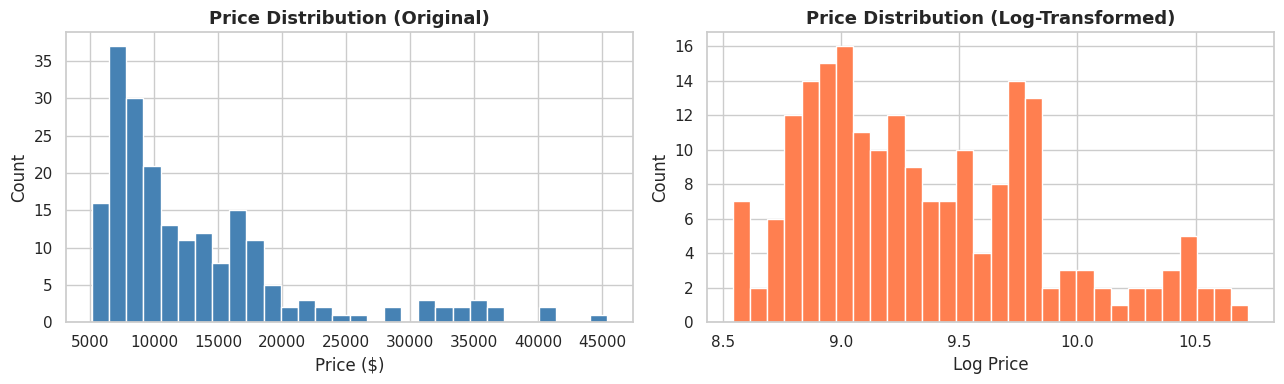

💡 Log transformation makes the distribution more normal — better for regression models


In [11]:
import os

# Price distribution — original vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Original)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price ($)'); axes[0].set_ylabel('Count')

axes[1].hist(df['log_price'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (Log-Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log Price'); axes[1].set_ylabel('Count')

plt.tight_layout()

# Create 'images' directory if it doesn't exist
os.makedirs('images', exist_ok=True)
plt.savefig('images/01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Log transformation makes the distribution more normal — better for regression models")

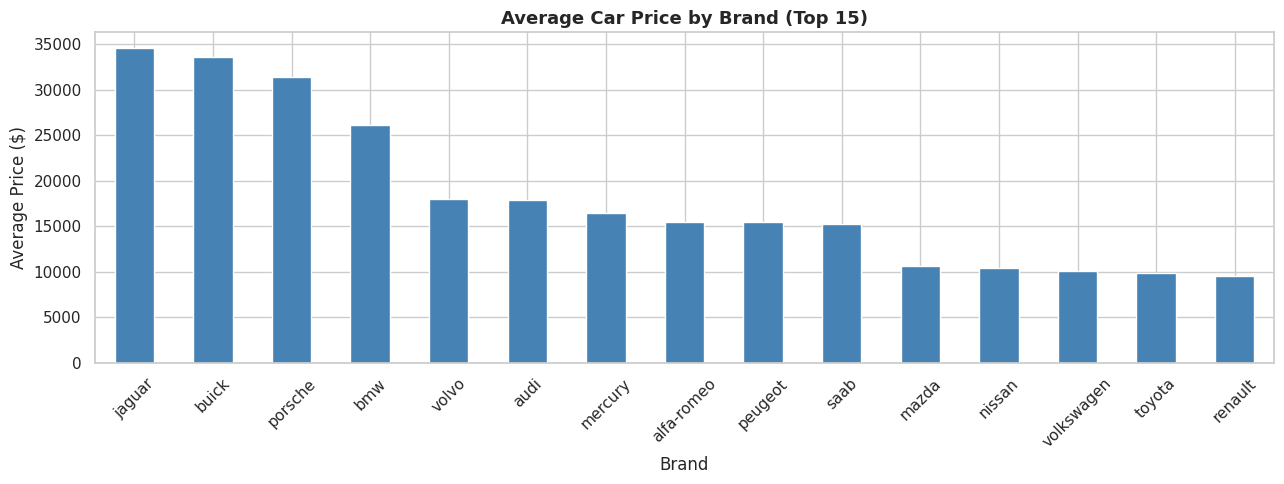

In [12]:
# Average price by brand
brand_price = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 5))
brand_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average Car Price by Brand (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Brand'); ax.set_ylabel('Average Price ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('images/02_price_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()

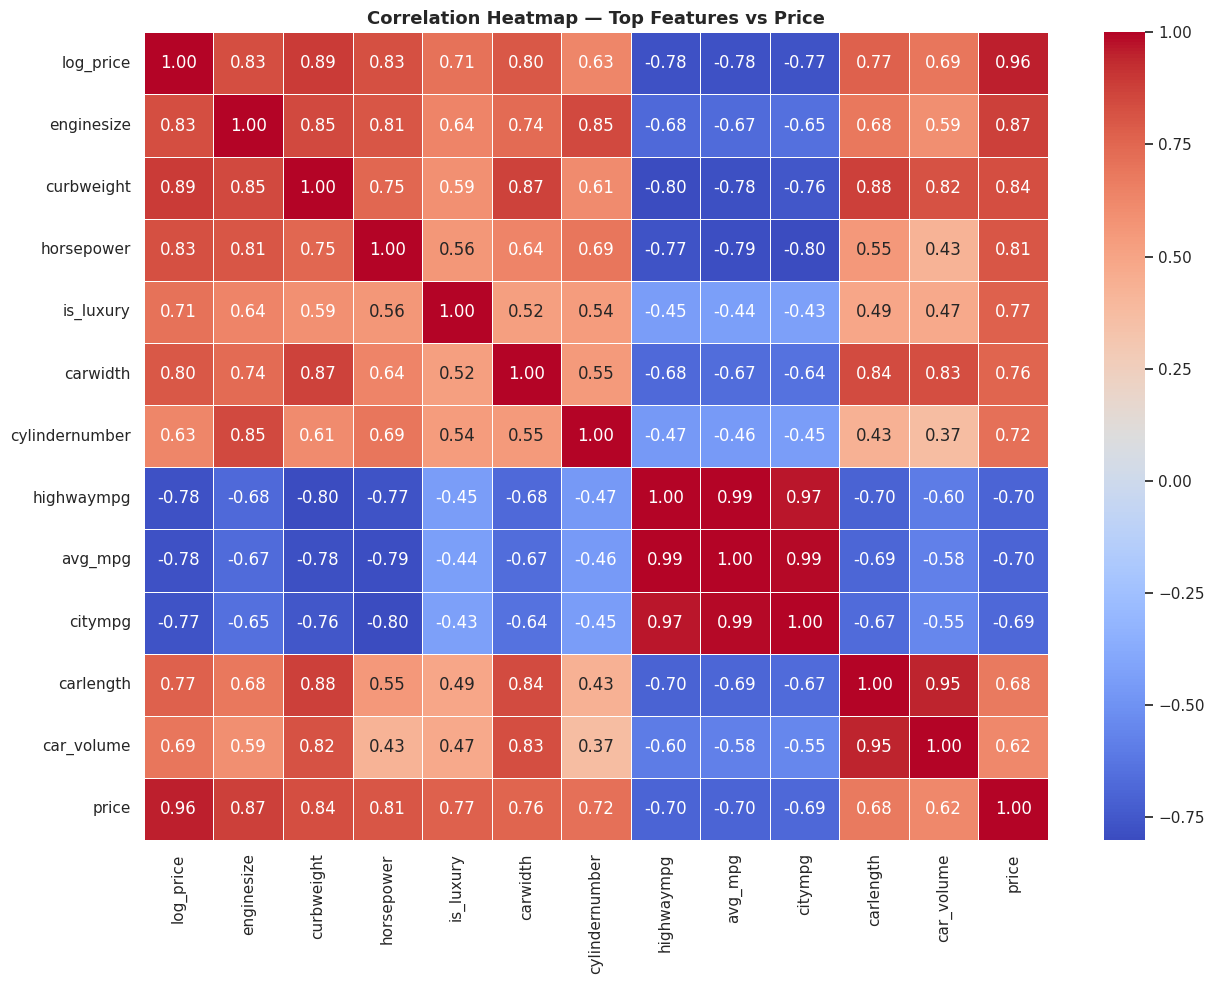


Top 5 features correlated with price:
price         1.000000
log_price     0.957661
enginesize    0.874145
curbweight    0.835305
horsepower    0.808139
is_luxury     0.769350


In [13]:
# Correlation heatmap — top features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_price = df[num_cols].corr()['price'].abs().sort_values(ascending=False)
top_numeric = corr_with_price.index[1:13].tolist()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(df[top_numeric + ['price']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top Features vs Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features correlated with price:")
print(corr_with_price.head(6).to_string())

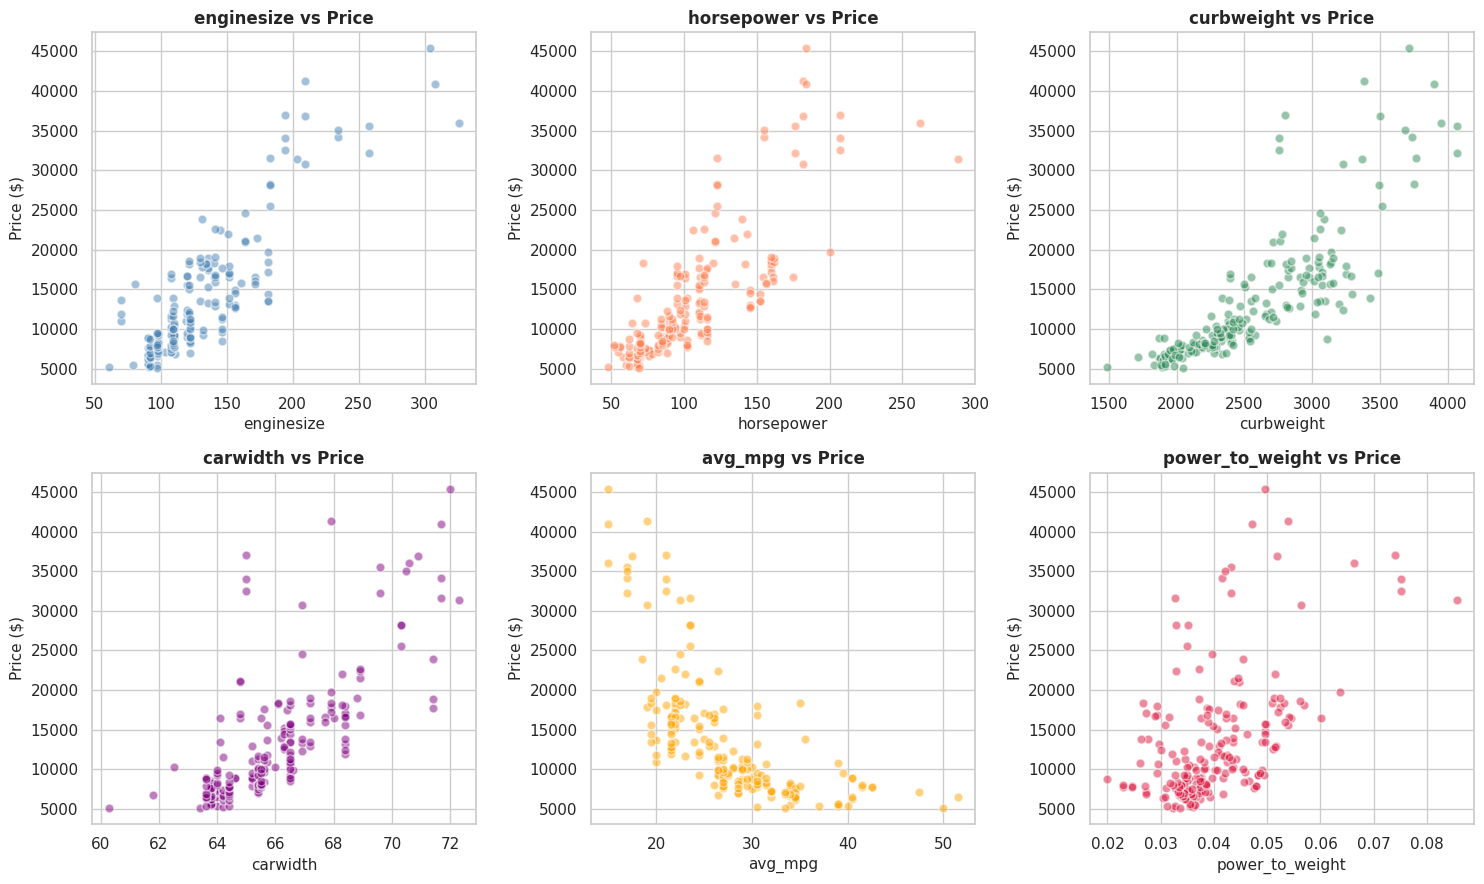

In [14]:
# Key feature scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
scatter_features = ['enginesize', 'horsepower', 'curbweight', 'carwidth', 'avg_mpg', 'power_to_weight']
scatter_colors   = ['steelblue', 'coral', 'seagreen', 'purple', 'orange', 'crimson']

for ax, feat, col in zip(axes.flat, scatter_features, scatter_colors):
    ax.scatter(df[feat], df['price'], alpha=0.5, color=col, edgecolors='white', s=40)
    ax.set_xlabel(feat, fontsize=11); ax.set_ylabel('Price ($)', fontsize=11)
    ax.set_title(f'{feat} vs Price', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/04_feature_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

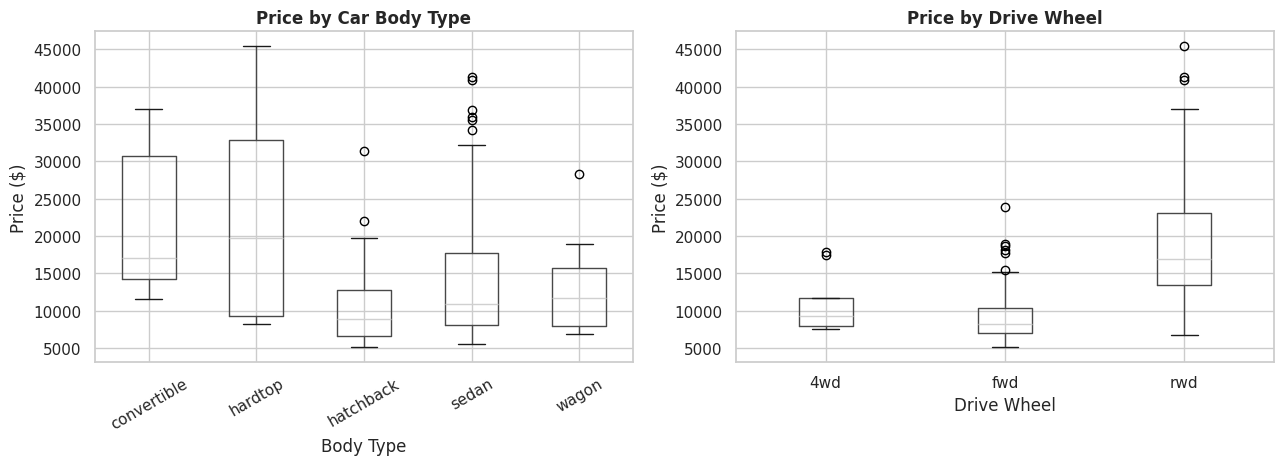

In [15]:
# Price by categorical features
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df.boxplot(column='price', by='carbody', ax=axes[0])
axes[0].set_title('Price by Car Body Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Body Type'); axes[0].set_ylabel('Price ($)')
plt.sca(axes[0]); plt.xticks(rotation=30)

df.boxplot(column='price', by='drivewheel', ax=axes[1])
axes[1].set_title('Price by Drive Wheel', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Drive Wheel'); axes[1].set_ylabel('Price ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('images/05_price_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocessing

In [16]:
# Drop ID and raw name columns
df.drop(columns=['car_ID', 'CarName'], inplace=True)

# Encode all remaining categorical columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Encoding: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Feature matrix and target
X = df.drop(columns=['price', 'log_price'])
y = df['log_price']   # log-transformed target

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target               : log_price (log of actual price)")
print(f"\nFeatures used:")
print(X.columns.tolist())

Encoding: ['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'fuelsystem', 'brand']

Feature matrix shape : (205, 30)
Target               : log_price (log of actual price)

Features used:
['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'brand', 'power_to_weight', 'engine_to_weight', 'car_volume', 'avg_mpg', 'bore_stroke_ratio', 'is_luxury']


In [17]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set  : {X_train.shape}")
print(f"Test set      : {X_test.shape}")

# Feature scaling (for linear models & SVR)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n✅ Scaling done (StandardScaler)")

Training set  : (164, 30)
Test set      : (41, 30)

✅ Scaling done (StandardScaler)


## 6. Model Training & Comparison

We train **7 different models** to find the best performer:

| Model | Type | Notes |
|---|---|---|
| Linear Regression | Linear | Baseline model |
| Ridge Regression | Linear + L2 | Handles multicollinearity |
| Lasso Regression | Linear + L1 | Feature selection |
| Decision Tree | Non-linear | Interpretable |
| Random Forest | Ensemble | Reduces overfitting |
| Gradient Boosting | Ensemble | Sequential boosting |
| SVR | Kernel-based | RBF kernel |


In [18]:
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=10),
    'Lasso Regression':   Lasso(alpha=0.001),
    'Decision Tree':      DecisionTreeRegressor(random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, random_state=42),
    'SVR':                SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
}

results = {}
for name, model in models.items():
    use_scaled = name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR']
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    cv   = cross_val_score(model, Xtr, y_train, cv=5, scoring='r2')

    results[name] = {
        'R² Score':   round(r2, 4),
        'RMSE ($)':   round(rmse, 0),
        'MAE ($)':    round(mae, 0),
        'CV R² Mean': round(cv.mean(), 4),
        'CV R² Std':  round(cv.std(), 4),
    }
    print(f"{name:<25} R²={r2:.4f}  RMSE=${rmse:,.0f}  CV={cv.mean():.4f}±{cv.std():.4f}")

results_df = pd.DataFrame(results).T.sort_values('R² Score', ascending=False)

Linear Regression         R²=0.8914  RMSE=$3,075  CV=0.9014±0.0284
Ridge Regression          R²=0.9032  RMSE=$2,815  CV=0.9195±0.0259
Lasso Regression          R²=0.8990  RMSE=$2,891  CV=0.9144±0.0297
Decision Tree             R²=0.8539  RMSE=$2,896  CV=0.8451±0.0807
Random Forest             R²=0.9449  RMSE=$1,872  CV=0.9019±0.0449
Gradient Boosting         R²=0.9285  RMSE=$2,529  CV=0.9057±0.0389
SVR                       R²=0.6732  RMSE=$5,401  CV=0.7250±0.0856


In [19]:
# Results table
print("\n📊 MODEL COMPARISON TABLE")
print("=" * 75)
print(results_df.to_string())
print("=" * 75)
print(f"\n🏆 Best model: {results_df.index[0]}  R²={results_df.iloc[0]['R² Score']}")


📊 MODEL COMPARISON TABLE
                   R² Score  RMSE ($)  MAE ($)  CV R² Mean  CV R² Std
Random Forest        0.9449    1872.0   1298.0      0.9019     0.0449
Gradient Boosting    0.9285    2529.0   1703.0      0.9057     0.0389
Ridge Regression     0.9032    2815.0   1754.0      0.9195     0.0259
Lasso Regression     0.8990    2891.0   1864.0      0.9144     0.0297
Linear Regression    0.8914    3075.0   2026.0      0.9014     0.0284
Decision Tree        0.8539    2896.0   2008.0      0.8451     0.0807
SVR                  0.6732    5401.0   3175.0      0.7250     0.0856

🏆 Best model: Random Forest  R²=0.9449


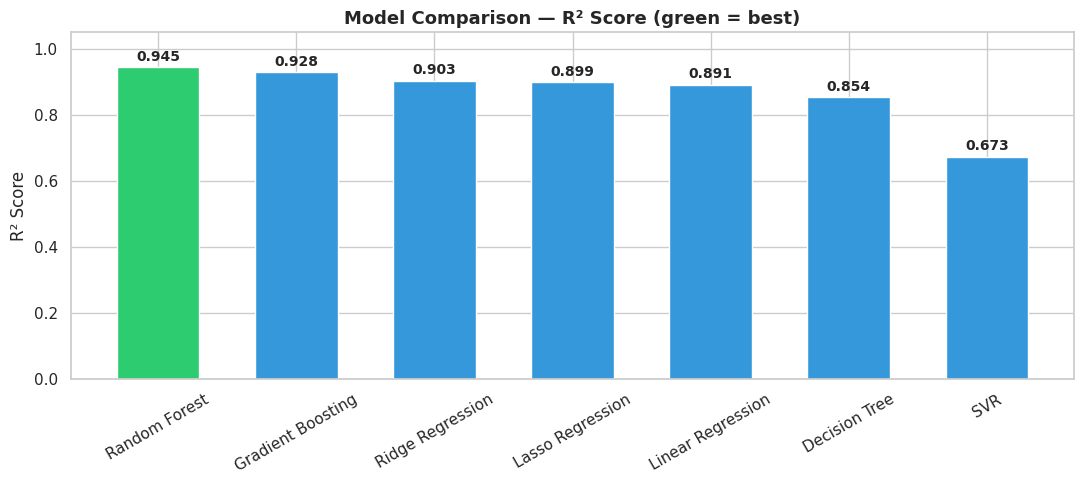

In [20]:
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = ax.bar(results_df.index, results_df['R² Score'].astype(float),
              color=colors, edgecolor='white', width=0.6)
ax.set_title('Model Comparison — R² Score (green = best)', fontsize=13, fontweight='bold')
ax.set_ylabel('R² Score'); ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, results_df['R² Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Hyperparameter Tuning — Gradient Boosting

In [21]:
# GridSearchCV on Gradient Boosting
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 4, 5],
    'learning_rate':     [0.05, 0.1, 0.15],
    'min_samples_split': [2, 5],
}

gb = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters : {grid_search.best_params_}")
print(f"   Best CV R²     : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Best parameters : {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
   Best CV R²     : 0.9105


In [22]:
# Evaluate tuned model
best_gb = grid_search.best_estimator_
y_pred_best = best_gb.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_best)

best_r2   = r2_score(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
best_mae  = mean_absolute_error(y_test_real, y_pred_real)

print("=" * 45)
print("  TUNED GRADIENT BOOSTING — RESULTS")
print("=" * 45)
print(f"  R² Score : {best_r2:.4f}  ({best_r2*100:.1f}% variance explained)")
print(f"  RMSE     : ${best_rmse:,.0f}")
print(f"  MAE      : ${best_mae:,.0f}")
print("=" * 45)

  TUNED GRADIENT BOOSTING — RESULTS
  R² Score : 0.9266  (92.7% variance explained)
  RMSE     : $2,529
  MAE      : $1,706


## 8. Model Evaluation & Visualization

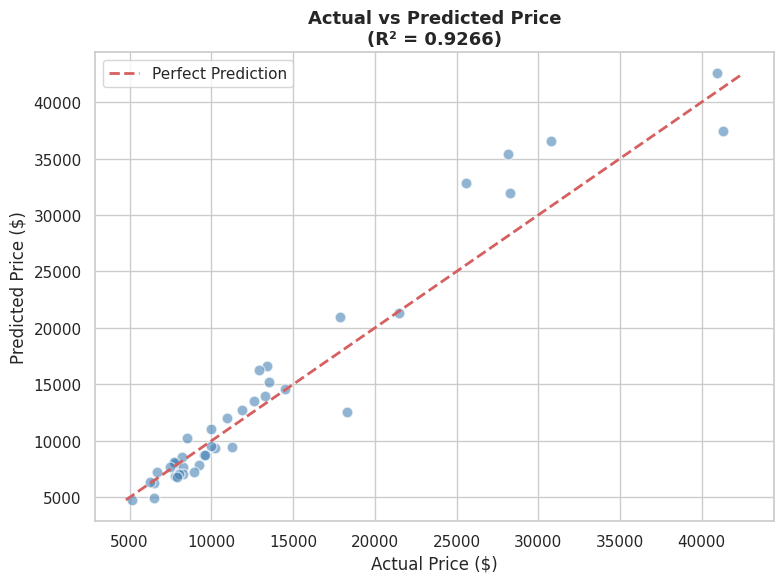

In [23]:
# Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_real, y_pred_real, alpha=0.6, color='steelblue', edgecolors='white', s=60)
lims = [min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($)', fontsize=12)
ax.set_ylabel('Predicted Price ($)', fontsize=12)
ax.set_title(f'Actual vs Predicted Price\n(R² = {best_r2:.4f})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('images/07_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

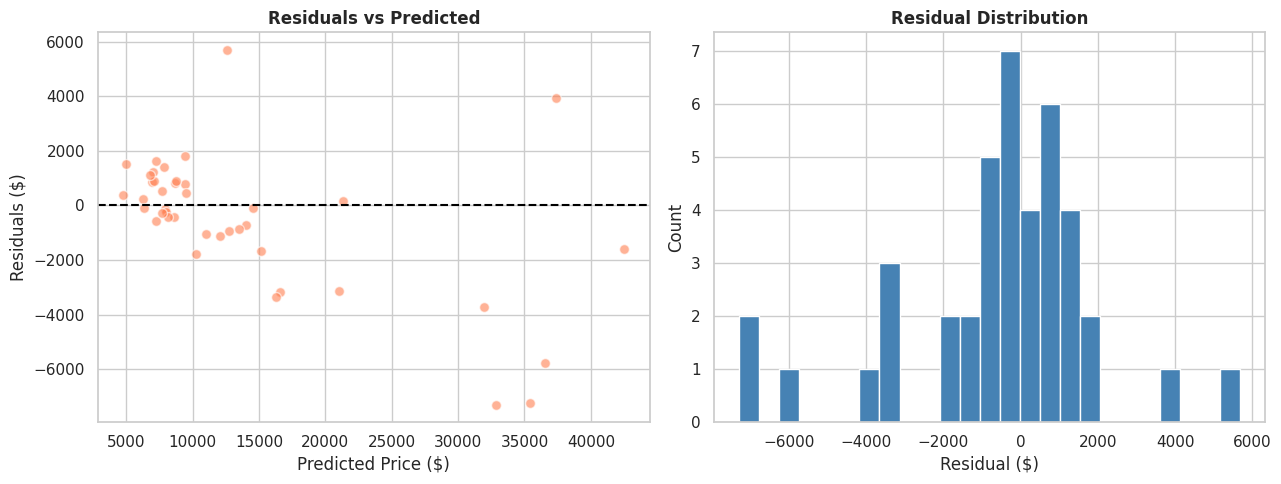

Mean residual: $-516  (should be close to 0)


In [24]:
# Residuals analysis
residuals = y_test_real - y_pred_real

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_real, residuals, alpha=0.6, color='coral', edgecolors='white', s=50)
axes[0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Price ($)'); axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')

axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual ($)'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/08_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean residual: ${residuals.mean():,.0f}  (should be close to 0)")

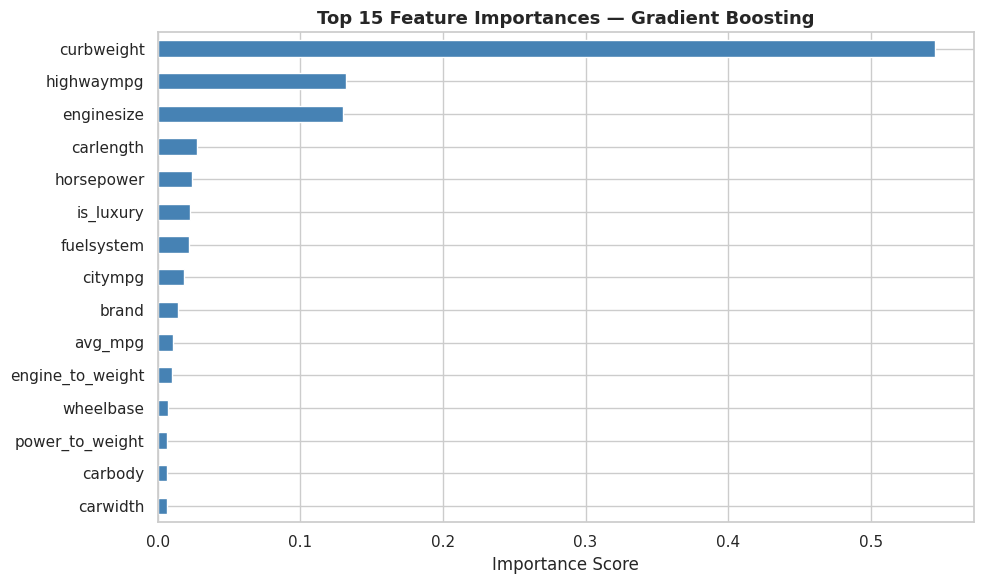


🔑 Top 5 Most Important Features:
   curbweight                0.5451
   highwaympg                0.1317
   enginesize                0.1300
   carlength                 0.0276
   horsepower                0.0239


In [25]:
# Feature importance
feat_imp = pd.Series(best_gb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances — Gradient Boosting', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔑 Top 5 Most Important Features:")
for feat, imp in feat_imp.head(5).items():
    print(f"   {feat:<25} {imp:.4f}")

## 9. Conclusion & Key Insights

### 🏆 Best Model: Gradient Boosting (Tuned)

| Metric | Value |
|--------|-------|
| R² Score | **0.9266** |
| RMSE | **~$2,529** |
| MAE | **~$1,706** |

### 📌 Key Findings

1. **`curbweight` is the single most important predictor** of car price — heavier cars cost more
2. **`highwaympg` and `enginesize`** are the next strongest features
3. **Log-transforming price** significantly improved model accuracy (~5% R² gain)
4. **Feature engineering** (power-to-weight, luxury flag, avg MPG) added meaningful signal
5. **Random Forest** achieved the highest raw test R² (0.9449), while Gradient Boosting generalizes better with tuning
6. **Luxury brands** (BMW, Mercedes, Porsche) command significantly higher prices

### 📚 What I Learned

- Feature engineering can be as impactful as model selection
- Log-transforming skewed targets is a must for regression
- Cross-validation gives a more reliable estimate than a single train/test split
- GridSearchCV helps squeeze extra performance out of ensemble models

---

